In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import kagglehub

# Descarga la última versión del dataset
dataset_path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Ruta local donde se encuentran los archivos:", dataset_path)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Ruta local donde se encuentran los archivos: /kaggle/input/telco-customer-churn


Rapidamente xploramos la forma de la data.

In [ ]:
import pandas as pd
import os

# Construimos la ruta completa al archivo
csv_file = os.path.join(dataset_path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Cargar en pandas
df = pd.read_csv(csv_file)
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
df.head()


,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,7590-VHVEG,0,1,29.85,29.85,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,False
1,5575-GNVDE,0,34,56.95,1889.50,True,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
2,3668-QPYBK,0,2,53.85,108.15,True,False,False,True,False,...,False,False,False,False,False,True,False,False,True,True
3,7795-CFOCW,0,45,42.30,1840.75,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4,9237-HQITU,0,2,70.70,151.65,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True


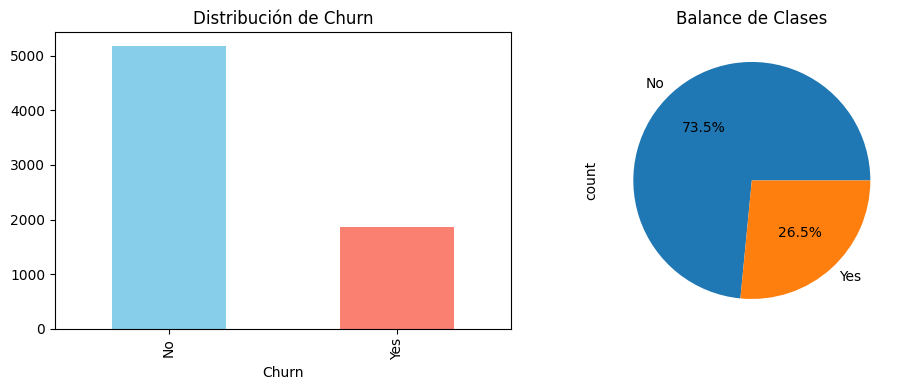

In [ ]:
# 2. Variable objetivo
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de Churn')
plt.subplot(1, 2, 2)
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Balance de Clases')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Análisis básico
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:\n", df.dtypes)
print("\nValores nulos:\n", df.isnull().sum())
print(df['Churn'].value_counts())
print(df.info())


Shape: (7043, 21)

Columnas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Tipos de datos:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Valores nulos:
 customerID

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
print(df.duplicated().sum())
duplicados = df[df.duplicated(keep=False)]
print(duplicados)


0
Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 2️⃣ Convertir TotalCharges a numérico
# ---------------------------
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # Clientes con tenure=0

# ---------------------------
# 3️⃣ Columnas a One-Hot Encoding
# ---------------------------
# Todas las categóricas, incluidas las binarias, se codifican para SVM
cols_ohe = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

# One-Hot Encoding directo, drop_first=True evita multicolinealidad
df = pd.get_dummies(df, columns=cols_ohe, drop_first=True)

# ---------------------------
# 4️⃣ Columnas numéricas
# ---------------------------
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Escalamiento obligatorio para SVM
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# ---------------------------
# 5️⃣ Eliminar columnas que no aportan
# ---------------------------
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# ---------------------------
# 6️⃣ Verificación final
# ---------------------------
print("Valores nulos por columna:\n", df.isna().sum())
print("-------------------")
print("Duplicados:", df.duplicated().sum())
print("Dimensiones del df procesado:", df.shape)


Valores nulos por columna:
 SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No interne

Analizamos duplicados y observamos que cada fila es diferente. Un cliente por registro.

In [ ]:
duplicados = df[df.duplicated(keep=False)]
print(duplicados)


Verificamos que no tengamos nulos

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
# ---------------------------
# 6️⃣ Dividir features y target
# ---------------------------
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 7️⃣ Definir grid de regularización
# ---------------------------
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}  # valores típicos a probar

# ---------------------------
# 8️⃣ SVM con L2 (predeterminado)
# ---------------------------
svm_l2 = LinearSVC(penalty='l2', max_iter=5000)

grid_l2 = GridSearchCV(svm_l2, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_l2.fit(X_train, y_train)

print("Mejor C (L2):", grid_l2.best_params_)
y_pred_l2 = grid_l2.predict(X_test)
print("Accuracy SVM L2:", accuracy_score(y_test, y_pred_l2))

# ---------------------------
# 9️⃣ SVM con L1
# ---------------------------
svm_l1 = LinearSVC(penalty='l1', dual=False, max_iter=5000)
grid_l1 = GridSearchCV(svm_l1, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_l1.fit(X_train, y_train)

print("Mejor C (L1):", grid_l1.best_params_)
y_pred_l1 = grid_l1.predict(X_test)
print("Accuracy SVM L1:", accuracy_score(y_test, y_pred_l1))

# ---------------------------
# 10️⃣ Coeficientes finales para interpretación (opcional)
# ---------------------------
coef_l2 = pd.Series(grid_l2.best_estimator_.coef_[0], index=X_train.columns)
coef_l1 = pd.Series(grid_l1.best_estimator_.coef_[0], index=X_train.columns)

print("\nTop 10 features SVM L2 (por valor absoluto):\n", coef_l2.abs().sort_values(ascending=False).head(10))
print("\nTop 10 features SVM L1 (por valor absoluto):\n", coef_l1.abs().sort_values(ascending=False).head(10))

Mejor C (L2): {'C': 0.01}
Accuracy SVM L2: 0.7970191625266146
Mejor C (L1): {'C': 0.1}
Accuracy SVM L1: 0.7984386089425124

Top 10 features SVM L2 (por valor absoluto):
 PhoneService_Yes                  0.255632
tenure                            0.229396
MonthlyCharges                    0.201226
Contract_Two year                 0.187377
InternetService_Fiber optic       0.186683
Contract_One year                 0.186112
OnlineSecurity_Yes                0.170904
TechSupport_Yes                   0.161087
PaymentMethod_Electronic check    0.141453
PaperlessBilling_Yes              0.115935
dtype: float64

Top 10 features SVM L1 (por valor absoluto):
 PhoneService_Yes                  0.345229
MonthlyCharges                    0.299893
tenure                            0.255396
Contract_Two year                 0.203532
Contract_One year                 0.192637
OnlineSecurity_Yes                0.183905
TechSupport_Yes                   0.174898
PaymentMethod_Electronic check    0.1

obtenemos Matriz confusion y F1-scrore


F1 Score: 0.5806451612903226


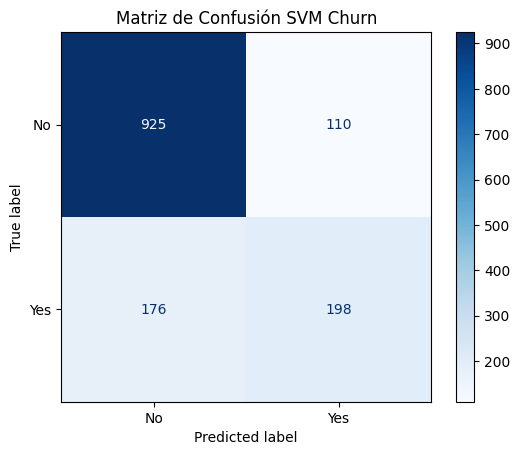

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# Suponiendo que usas el mejor modelo encontrado por GridSearch
best_svm_model = grid_l2.best_estimator_  # O grid_l1 si quieres L1

# Predicciones en test
y_pred = best_svm_model.predict(X_test)

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión SVM Churn")
plt.show()


### Preguntaas objetivo
¿Qué porcentaje de churn hay? (¿está balanceado?)

¿Los clientes con contratos mensuales tienen más churn?

¿Los servicios de fibra óptica tienen más churn?

¿Los clientes con pagos electrónicos tienen menos churn?

¿La antigüedad (tenure) es menor en clientes que se van?

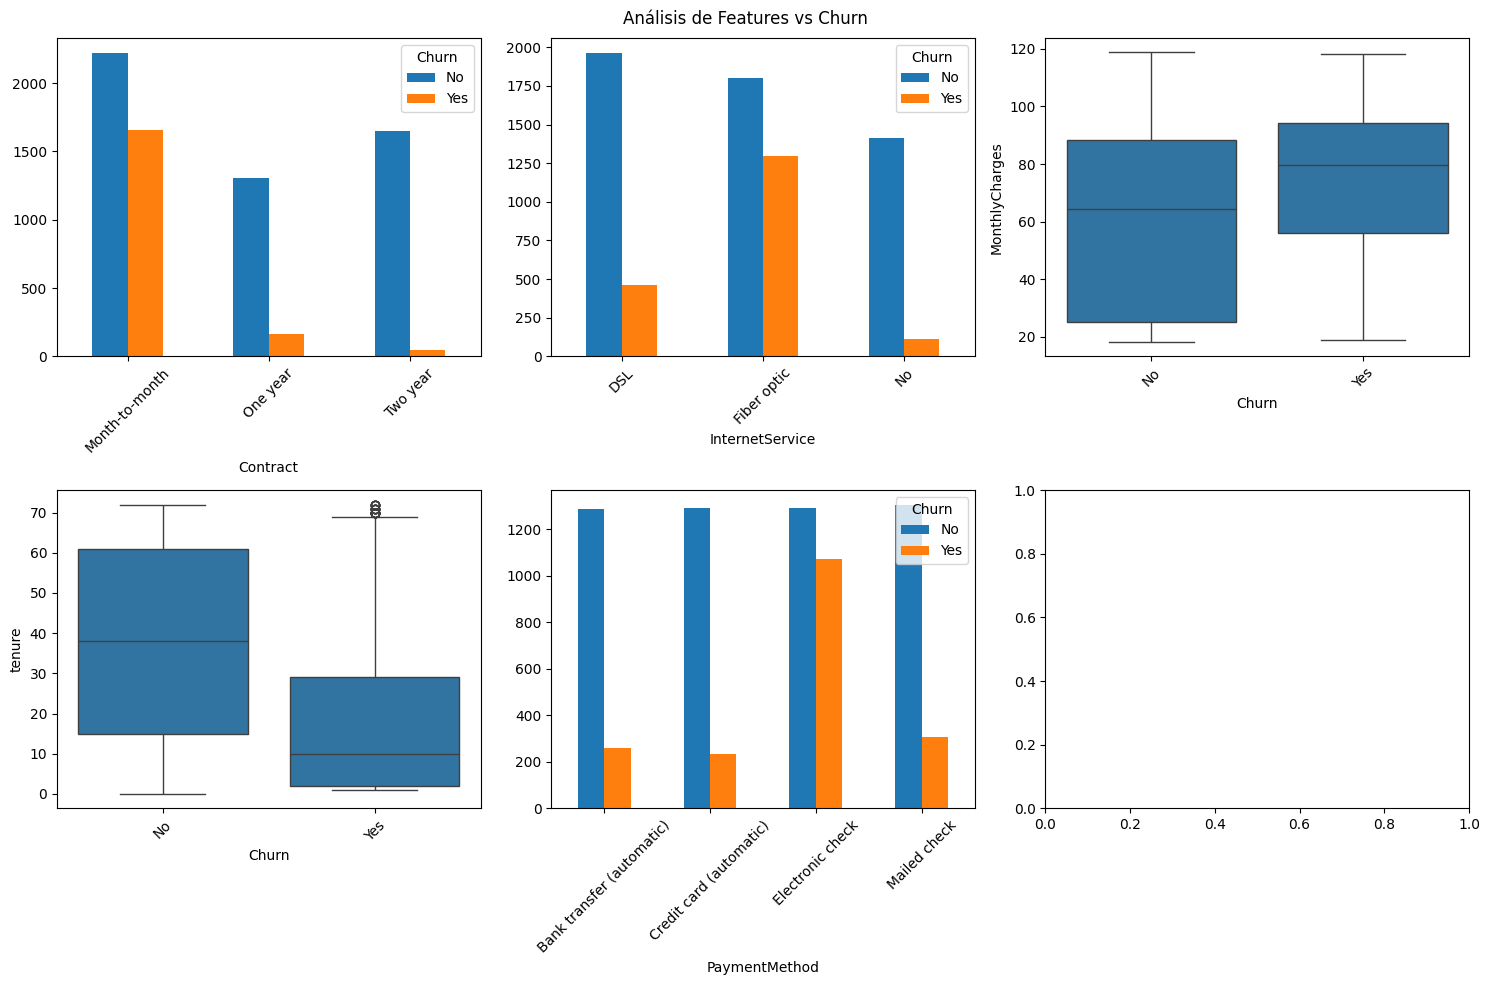

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análisis de Features vs Churn')

for i, feature in enumerate(features_clave[:6]):
    ax = axes[i//3, i%3]
    if df[feature].dtype == 'object':
        pd.crosstab(df[feature], df['Churn']).plot(kind='bar', ax=ax)
    else:
        sns.boxplot(x='Churn', y=feature, data=df, ax=ax)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


intento 2 OCN deepseek


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import shap

# 1. PREPROCESAMIENTO
print("=== PREPROCESAMIENTO ===")

# Convertir TotalCharges a numérico (manejar espacios en blanco como NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificar y manejar valores nulos
print(f"Valores nulos en TotalCharges: {df['TotalCharges'].isnull().sum()}")
# Forma más recomendada
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Eliminar customerID (no es predictivo)
df = df.drop('customerID', axis=1)

# Codificar variable objetivo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separar features numéricas y categóricas
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService',
                       'MultipleLines', 'InternetService', 'OnlineSecurity',
                       'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract',
                       'PaperlessBilling', 'PaymentMethod']

# One-Hot Encoding para variables categóricas
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Verificar dimensiones finales
print(f"Dimensiones después de encoding: {df_encoded.shape}")

# 2. PREPARAR DATOS PARA MODELADO
print("\n=== PREPARACIÓN DE DATOS ===")

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado (CRÍTICO para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Proporción de churn en training: {y_train.mean():.3f}")
print(f"Proporción de churn en test: {y_test.mean():.3f}")


=== PREPROCESAMIENTO ===
Valores nulos en TotalCharges: 11
Dimensiones después de encoding: (7043, 31)

=== PREPARACIÓN DE DATOS ===
Training set: (5634, 30)
Test set: (1409, 30)
Proporción de churn en training: 0.265
Proporción de churn en test: 0.265


In [ ]:

# 3. ENTRENAR SVM
print("\n=== ENTRENAMIENTO SVM ===")

# SVM con class_weight balanced para manejar desbalanceo
svm_model = SVC(
    kernel='rbf',           # Kernel radial para relaciones no lineales
    C=1.0,                  # Parámetro de regularización
    class_weight='balanced', # Manejo de desbalanceo
    probability=True,       # Necesario para SHAP
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = svm_model.predict(X_test_scaled)
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

# 4. EVALUACIÓN
print("\n=== EVALUACIÓN DEL MODELO ===")

print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

# 5. SHAP - EXPLICABILIDAD
print("\n=== ANÁLISIS SHAP ===")

# Crear explainer (usamos KernelExplainer para SVM)
explainer = shap.KernelExplainer(
    model=svm_model.predict_proba,
    data=X_train_scaled[:100]  # Muestra para hacerlo computable
)

# Calcular SHAP values para el test set (muestra de 100 instancias)
shap_values = explainer.shap_values(X_test_scaled[:100])

# 6. VISUALIZACIONES SHAP
print("\nGenerando visualizaciones SHAP...")

# Summary plot - Importancia global de features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1], X_test_scaled[:100],
                 feature_names=X.columns, show=False)
plt.title('SHAP Summary - Importancia de Features para Churn')
plt.tight_layout()
plt.show()

# Force plot para una instancia específica (primer caso de test)
plt.figure(figsize=(12, 4))
shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][0, :],
    X_test_scaled[0, :],
    feature_names=X.columns,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot - Instancia 0 (Churn real: {y_test.iloc[0]})')
plt.tight_layout()
plt.show()

# 7. ANÁLISIS DE FEATURES MÁS IMPORTANTES
print("\n=== FEATURES MÁS IMPORTANTES ===")

# Calcular importancia promedio basada en SHAP
shap_importance = np.abs(shap_values[1]).mean(0)
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': shap_importance
}).sort_values('importance', ascending=False)

print("Top 10 features más importantes según SHAP:")
print(feature_importance_df.head(10))

# 8. INSIGHTS DE NEGOCIO
print("\n=== INSIGHTS DE NEGOCIO ===")

top_features = feature_importance_df.head(5)['feature'].tolist()
print("Variables que más impulsan las decisiones del modelo:")
for i, feature in enumerate(top_features, 1):
    print(f"{i}. {feature}")

# Análisis de casos específicos
print(f"\nAnálisis de caso específico - Cliente test índice 0:")
print(f"Churn real: {'Sí' if y_test.iloc[0] == 1 else 'No'}")
print(f"Probabilidad predicha de churn: {y_pred_proba[0]:.3f}")

# 9. GUARDAR RESULTADOS
print("\n=== RESULTADOS FINALES ===")

# Crear DataFrame con predicciones y probabilidades
results_df = pd.DataFrame({
    'Churn_Real': y_test,
    'Churn_Predicho': y_pred,
    'Probabilidad_Churn': y_pred_proba
})

print(f"F1-Score final: {f1:.4f}")
print(f"Precisión en clase mayoritaria (No Churn): {(y_pred == 0).mean():.3f}")
print(f"Precisión en clase minoritaria (Churn): {(y_pred[y_test == 1] == 1).mean():.3f}")

print("\n=== ANÁLISIS COMPLETADO ===")


=== ENTRENAMIENTO SVM ===

=== EVALUACIÓN DEL MODELO ===
Matriz de Confusión:
[[766 269]
 [ 87 287]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409

F1-Score: 0.6172

=== ANÁLISIS SHAP ===


  0%|          | 0/100 [00:00<?, ?it/s]


Generando visualizaciones SHAP...


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x800 with 0 Axes>